# Battery Data Evaluation

# Huber

In [1]:
# Import required libraries
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import joblib
import os
import gc
from tqdm import tqdm
from typing import Dict, Any, List, Tuple
import matplotlib.pyplot as plt
import seaborn as sns


print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
import joblib
from pathlib import Path

# Paths that match your prepare script output
base_dir = Path("data/battery")
battery_data_path = base_dir / "LLmodel.pkl"
hl_data_path = base_dir / "HLmodel.pkl"
abstraction_data_path = base_dir / "abstraction_data.pkl"

try:
    ll_data = joblib.load(battery_data_path)
    hl_data = joblib.load(hl_data_path)
    abstraction_data = joblib.load(abstraction_data_path)
    
    print("✅ Battery data loaded successfully")
    print(f"LL data keys: {list(ll_data.keys())}")
    print(f"HL data keys: {list(hl_data.keys())}")
    print(f"Abstraction data keys: {list(abstraction_data.keys())}")
    
    # Extract key components
    Dll_samples = ll_data['data']          # Dict[Intervention, np.ndarray] (observational + interventional)
    Dhl_samples = hl_data['data']
    Dll_det     = ll_data['deterministic']
    Dhl_det     = hl_data['deterministic']
    Dll_noise   = ll_data['noise']
    Dhl_noise   = hl_data['noise']
    row_idx_ll  = ll_data['row_idx']
    row_idx_hl  = hl_data['row_idx']
    omega       = abstraction_data['omega']
    
    print("\nAvailable interventions:")
    print(f"LL keys: {list(Dll_samples.keys())}")
    print(f"HL keys: {list(Dhl_samples.keys())}")
    print(f"\nOmega mapping: {omega}")
    
except Exception as e:
    print(f"❌ Error loading battery data: {e}")
    raise


✅ Battery data loaded successfully
LL data keys: ['graph', 'intervention_set', 'coeffs', 'intercepts', 'data', 'noise', 'node_order', 'deterministic', 'row_idx']
HL data keys: ['graph', 'intervention_set', 'coeffs', 'intercepts', 'data', 'noise', 'node_order', 'deterministic', 'row_idx']
Abstraction data keys: ['T', 'omega']

Available interventions:
LL keys: [None, <models.Intervention object at 0x171d53470>, <models.Intervention object at 0x171d534d0>, <models.Intervention object at 0x171d53560>, <models.Intervention object at 0x171d53590>]
HL keys: [None, <models.Intervention object at 0x171d53950>, <models.Intervention object at 0x171d538c0>, <models.Intervention object at 0x171d53860>]

Omega mapping: {None: None, <models.Intervention object at 0x16f4acce0>: <models.Intervention object at 0x1716e80e0>, <models.Intervention object at 0x171d53440>: <models.Intervention object at 0x171d533e0>, <models.Intervention object at 0x171d53e30>: <models.Intervention object at 0x171d53e00>, <

In [3]:
# --- Rebuild folds exactly like in optimization ---
def make_stratified_9010_splits(Dhl_obs: np.ndarray, test_size: float, seeds: List[int]) -> List[dict]:
    """Rebuild the same stratified splits used in optimization."""
    assert Dhl_obs.ndim == 2 and 0.0 < test_size < 1.0
    N = Dhl_obs.shape[0]
    y = Dhl_obs[:, 0]  # Use CG values for stratification
    
    label_to_indices: Dict[Any, List[int]] = {}
    for idx, lab in enumerate(y):
        label_to_indices.setdefault(lab, []).append(idx)
    
    folds = []
    for seed in seeds:
        rng = np.random.default_rng(seed)
        test_idx = []
        for _, idxs in label_to_indices.items():
            n = len(idxs)
            n_test = max(1, int(round(test_size * n)))
            chosen = rng.choice(idxs, size=n_test, replace=False)
            test_idx.append(chosen)
        test_idx = np.unique(np.concatenate(test_idx))
        train_idx = np.setdiff1d(np.arange(N), test_idx)
        folds.append({"train": train_idx, "test": test_idx, "seed": seed})
    return folds

# Build the same folds as optimization (use same seeds and test_size)
Dhl_obs_full = hl_data["data"][None]  # observational aligned (N, d_h)
folds = make_stratified_9010_splits(Dhl_obs_full, test_size=0.1, seeds=[42, 43, 44, 45, 46])
print(f"✅ Rebuilt {len(folds)} folds")
print(f"Test sizes: {[len(f['test']) for f in folds]}")
print(f"Train sizes: {[len(f['train']) for f in folds]}")

✅ Rebuilt 5 folds
Test sizes: [7, 7, 7, 7, 7]
Train sizes: [57, 57, 57, 57, 57]


In [4]:
# Load optimization results
results_dir = 'data/battery/results_empirical_9010'

try:
    # List all result files
    result_files = [f for f in os.listdir(results_dir) if f.endswith('.pkl')]
    print(f"Found {len(result_files)} result files:")
    for f in result_files:
        print(f"  - {f}")
    
    # Load and combine all method results
    all_results = {}
    
    # Load DiRoCA results
    if 'diroca_cv_results_empirical.pkl' in result_files:
        diroca_results = joblib.load(os.path.join(results_dir, 'diroca_cv_results_empirical.pkl'))
        print(f"\n✅ DiRoCA results loaded: {len(diroca_results)} epsilon configurations")
        all_results.update(diroca_results)
    
    # Load GradCA results
    if 'gradca_cv_results_empirical.pkl' in result_files:
        gradca_results = joblib.load(os.path.join(results_dir, 'gradca_cv_results_empirical.pkl'))
        print(f"✅ GradCA results loaded: {len(gradca_results)} folds")
        all_results['gradca'] = gradca_results
    
    # Load BaryCA results
    if 'baryca_cv_results_empirical.pkl' in result_files:
        baryca_results = joblib.load(os.path.join(results_dir, 'baryca_cv_results_empirical.pkl'))
        print(f"✅ BaryCA results loaded: {len(baryca_results)} folds")
        all_results['baryca'] = baryca_results
    
    # Load Abs-LiNGAM results
    if 'abslingam_cv_results_empirical.pkl' in result_files:
        abslingam_results = joblib.load(os.path.join(results_dir, 'abslingam_cv_results_empirical.pkl'))
        print(f"✅ Abs-LiNGAM results loaded: {len(abslingam_results)} folds")
        all_results['abslingam'] = abslingam_results
    
    print(f"\n✅ All results loaded successfully!")
    print(f"Combined result keys: {list(all_results.keys())}")
        
except Exception as e:
    print(f"❌ Error loading results: {e}")
    all_results = {}

Found 8 result files:
  - abslingam_cv_results_empirical.pkl
  - gradca_empirical_splits.pkl
  - gradca_cv_results_empirical.pkl
  - diroca_cv_results_empirical.pkl
  - abslingam_empirical_splits.pkl
  - diroca_empirical_splits.pkl
  - baryca_empirical_splits.pkl
  - baryca_cv_results_empirical.pkl

✅ DiRoCA results loaded: 6 epsilon configurations
✅ GradCA results loaded: 5 folds
✅ BaryCA results loaded: 5 folds
✅ Abs-LiNGAM results loaded: 5 folds

✅ All results loaded successfully!
Combined result keys: ['epsilon_0.558_delta_0.417', 'epsilon_1.0_delta_1.0', 'epsilon_2.0_delta_2.0', 'epsilon_4.0_delta_4.0', 'epsilon_8.0_delta_8.0', 'epsilon_0.5_delta_0.5', 'gradca', 'baryca', 'abslingam']


In [5]:
# import os
# import joblib

# results_dir = 'data/battery/results_empirical_9010'

# try:
#     # List all result files
#     result_files = [f for f in os.listdir(results_dir) if f.endswith('.pkl')]
#     print(f"Found {len(result_files)} result files:")
#     for f in result_files:
#         print(f"  - {f}")
    
#     # Load and combine all method results
#     all_results = {}
    
#     # Load DiRoCA results
#     if 'diroca_cv_results_empirical.pkl' in result_files:
#         diroca_results = joblib.load(os.path.join(results_dir, 'diroca_cv_results_empirical.pkl'))
#         print(f"\n✅ DiRoCA results loaded: {len(diroca_results)} epsilon configurations")
#         all_results['diroca'] = diroca_results   # <-- change here
    
#     # Load GradCA results
#     if 'gradca_cv_results_empirical.pkl' in result_files:
#         gradca_results = joblib.load(os.path.join(results_dir, 'gradca_cv_results_empirical.pkl'))
#         print(f"✅ GradCA results loaded: {len(gradca_results)} folds")
#         all_results['gradca'] = gradca_results
    
#     # Load BaryCA results
#     if 'baryca_cv_results_empirical.pkl' in result_files:
#         baryca_results = joblib.load(os.path.join(results_dir, 'baryca_cv_results_empirical.pkl'))
#         print(f"✅ BaryCA results loaded: {len(baryca_results)} folds")
#         all_results['baryca'] = baryca_results
    
#     # Load Abs-LiNGAM results
#     if 'abslingam_cv_results_empirical.pkl' in result_files:
#         abslingam_results = joblib.load(os.path.join(results_dir, 'abslingam_cv_results_empirical.pkl'))
#         print(f"✅ Abs-LiNGAM results loaded: {len(abslingam_results)} folds")
#         all_results['abslingam'] = abslingam_results
    
#     print(f"\n✅ All results loaded successfully!")
#     print(f"Combined result keys (methods): {list(all_results.keys())}")
        
# except Exception as e:
#     print(f"❌ Error loading results: {e}")
#     all_results = {}


In [6]:
# --- T Matrix Orientation Helper ---
def coerce_T(T, d_h, d_l):
    """Ensure T matrix has correct orientation (d_h, d_l)."""
    T = np.asarray(T)
    if T.shape == (d_h, d_l): 
        return T
    if T.shape == (d_l, d_h): 
        return T.T
    raise ValueError(f"Unexpected T shape {T.shape}, expected {(d_h, d_l)} or {(d_l, d_h)}")

# Get dimensions for T matrix validation
d_h = hl_data["data"][None].shape[1]  # HL features
d_l = ll_data["data"][None].shape[1]  # LL features
print(f"Expected T matrix shape: ({d_h}, {d_l})")
print(f"HL features: {d_h}, LL features: {d_l}")

Expected T matrix shape: (2, 3)
HL features: 2, LL features: 3


In [7]:
# Contamination function for battery data (similar to CMNIST but for tabular data)
def apply_huber_contamination_battery(clean_data, alpha, noise_scale, noise_dims, seed=None, loc=0.0):
    """Contaminates specific dimensions of battery data with zero-mean noise.
    
    Args:
        clean_data: np.ndarray or torch.Tensor of shape (n_samples, n_features)
        alpha: contamination fraction (0.0 = no contamination, 1.0 = full contamination)
        noise_scale: standard deviation of noise
        noise_dims: indices or slice of dimensions to contaminate
        seed: random seed for reproducibility
        loc: mean of noise distribution (default 0.0 for zero-mean)
    
    Returns:
        contaminated_data: same type as input
    """
    if alpha == 0 or noise_scale == 0:
        return clean_data if isinstance(clean_data, torch.Tensor) else torch.tensor(clean_data, dtype=torch.float32)

    data_tensor = clean_data if isinstance(clean_data, torch.Tensor) else torch.tensor(clean_data, dtype=torch.float32)
    data_cont = data_tensor.clone().to(torch.float32)
    data_to_noise = data_cont[:, noise_dims].data

    rng = np.random.default_rng(seed)
    noise = rng.normal(loc=loc, scale=noise_scale, size=data_to_noise.shape).astype(np.float32)
    noise_tensor = torch.tensor(noise, dtype=torch.float32, device=data_tensor.device)
    noisy_slice = data_to_noise + noise_tensor

    if alpha >= 1.0:
        data_cont[:, noise_dims] = noisy_slice
        return data_cont

    n_samples = data_tensor.shape[0]
    n_contaminate = int(alpha * n_samples)
    if n_contaminate == 0: 
        return data_cont

    idx_to_contaminate = rng.choice(n_samples, size=n_contaminate, replace=False)
    data_cont[idx_to_contaminate, noise_dims] = noisy_slice[idx_to_contaminate]
    return data_cont

print("✅ Contamination function defined for battery data.")

✅ Contamination function defined for battery data.


In [8]:
# Error calculation function for battery data (FIXED normalization)
def calculate_empirical_error_battery(T_matrix, Dll_test, Dhl_test):
    """Calculates abstraction error for the linear T matrix on battery data.
    
    Args:
        T_matrix: transformation matrix (d_h, d_l)
        Dll_test: low-level test data (n_test, d_l)
        Dhl_test: high-level test data (n_test, d_h)
    
    Returns:
        error: Frobenius norm squared error per sample per dimension
    """
    try:
        T_matrix = T_matrix if isinstance(T_matrix, torch.Tensor) else torch.tensor(T_matrix, dtype=torch.float32)
        Dll_test = Dll_test if isinstance(Dll_test, torch.Tensor) else torch.tensor(Dll_test, dtype=torch.float32)
        Dhl_test = Dhl_test if isinstance(Dhl_test, torch.Tensor) else torch.tensor(Dhl_test, dtype=torch.float32)
        
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        T_matrix = T_matrix.to(device)
        Dll_test = Dll_test.to(device)
        Dhl_test = Dhl_test.to(device)

        # Check dimension compatibility
        if T_matrix.shape[1] != Dll_test.shape[1]: 
            print(f"Dimension mismatch T vs LL: T={T_matrix.shape}, LL={Dll_test.shape}")
            return float('inf')
        if T_matrix.shape[0] != Dhl_test.shape[1]: 
            print(f"Dimension mismatch T vs HL: T={T_matrix.shape}, HL={Dhl_test.shape}")
            return float('inf')

        with torch.no_grad():
            Dhl_pred = Dll_test @ T_matrix.T  # (n_test, d_l) @ (d_l, d_h) = (n_test, d_h)
            diff = Dhl_pred - Dhl_test
            # FIXED: Use same normalization as optimization loop
            err = torch.norm(diff, p='fro')**2 / (diff.shape[0] * diff.shape[1])
        return float(err.item())

    except Exception as e:
        print(f"Error in calculate_empirical_error_battery: {e}")
        return float('inf')

print("✅ Error calculation function defined for battery data.")

✅ Error calculation function defined for battery data.


In [9]:
# # --- T Matrix Orientation Helper ---
# def coerce_T(T, d_h, d_l):
#     """Ensure T matrix has correct orientation (d_h, d_l)."""
#     T = np.asarray(T)
#     if T.shape == (d_h, d_l):
#         return T
#     if T.shape == (d_l, d_h):
#         return T.T
#     raise ValueError(f"Unexpected T shape {T.shape}, expected {(d_h, d_l)} or {(d_l, d_h)}")

# # Get dimensions for T matrix validation (observational buckets)
# d_h = hl_data["data"][None].shape[1]  # HL features
# d_l = ll_data["data"][None].shape[1]  # LL features
# print(f"Expected T matrix shape: ({d_h}, {d_l})")
# print(f"HL features: {d_h}, LL features: {d_l}")


In [10]:
# # Error calculation function for battery data (FIXED normalization)
# def calculate_empirical_error_battery(T_matrix, Dll_test, Dhl_test):
#     """Calculates abstraction error for the linear T matrix on battery data.
    
#     Args:
#         T_matrix: transformation matrix (d_h, d_l) or (d_l, d_h)
#         Dll_test: low-level test data (n_test, d_l)
#         Dhl_test: high-level test data (n_test, d_h)
    
#     Returns:
#         error: Frobenius norm squared error per sample per dimension
#     """
#     try:
#         # Coerce orientation first using dims inferred from data
#         expected_d_l = Dll_test.shape[1]
#         expected_d_h = Dhl_test.shape[1]
#         T_matrix = coerce_T(T_matrix, expected_d_h, expected_d_l)

#         T_matrix = T_matrix if isinstance(T_matrix, torch.Tensor) else torch.tensor(T_matrix, dtype=torch.float32)
#         Dll_test = Dll_test if isinstance(Dll_test, torch.Tensor) else torch.tensor(Dll_test, dtype=torch.float32)
#         Dhl_test = Dhl_test if isinstance(Dhl_test, torch.Tensor) else torch.tensor(Dhl_test, dtype=torch.float32)
        
#         device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#         T_matrix = T_matrix.to(device)
#         Dll_test = Dll_test.to(device)
#         Dhl_test = Dhl_test.to(device)

#         # Final dimension sanity checks
#         if T_matrix.shape[1] != Dll_test.shape[1]:
#             print(f"Dimension mismatch T vs LL: T={T_matrix.shape}, LL={Dll_test.shape}")
#             return float('inf')
#         if T_matrix.shape[0] != Dhl_test.shape[1]:
#             print(f"Dimension mismatch T vs HL: T={T_matrix.shape}, HL={Dhl_test.shape}")
#             return float('inf')

#         with torch.no_grad():
#             # (n_test, d_l) @ (d_l, d_h) = (n_test, d_h)
#             Dhl_pred = Dll_test @ T_matrix.T
#             diff = Dhl_pred - Dhl_test
#             # Same normalization as optimization objective
#             err = torch.norm(diff, p='fro')**2 / (diff.shape[0] * diff.shape[1])
#         return float(err.item())

#     except Exception as e:
#         print(f"Error in calculate_empirical_error_battery: {e}")
#         return float('inf')

# print("✅ Error calculation function defined for battery data.")


In [11]:
# def apply_huber_contamination_battery(clean_data, alpha, noise_scale, noise_dims, seed=None, loc=0.0):
#     """Contaminates specific dimensions of battery data with zero-mean noise.
    
#     Args:
#         clean_data: np.ndarray or torch.Tensor of shape (n_samples, n_features)
#         alpha: contamination fraction (0.0 = no contamination, 1.0 = full contamination)
#         noise_scale: standard deviation of noise
#         noise_dims: indices or slice of dimensions to contaminate
#         seed: random seed for reproducibility
#         loc: mean of noise distribution (default 0.0 for zero-mean)
    
#     Returns:
#         contaminated_data: torch.Tensor of shape (n_samples, n_features)
#     """
#     # Convert to tensor once
#     data_tensor = clean_data if isinstance(clean_data, torch.Tensor) \
#         else torch.tensor(clean_data, dtype=torch.float32)

#     # Trivial cases: just return a clone tensor
#     if alpha == 0 or noise_scale == 0:
#         return data_tensor.clone()

#     data_cont = data_tensor.clone().to(torch.float32)
#     data_to_noise = data_cont[:, noise_dims]

#     rng = np.random.default_rng(seed)
#     noise = rng.normal(loc=loc, scale=noise_scale, size=data_to_noise.shape).astype(np.float32)
#     noise_tensor = torch.tensor(noise, dtype=torch.float32, device=data_tensor.device)
#     noisy_slice = data_to_noise + noise_tensor

#     if alpha >= 1.0:
#         data_cont[:, noise_dims] = noisy_slice
#         return data_cont

#     n_samples = data_tensor.shape[0]
#     n_contaminate = int(alpha * n_samples)
#     if n_contaminate == 0:
#         return data_cont

#     idx_to_contaminate = rng.choice(n_samples, size=n_contaminate, replace=False)
#     data_cont[idx_to_contaminate, noise_dims] = noisy_slice[idx_to_contaminate]
#     return data_cont

# print("✅ Contamination function defined for battery data.")


In [12]:
# Evaluation parameters
N_TRIALS = 5
NOISE_SCALE_FOR_ALPHA1 = 5.0  # Standard deviation for full contamination
ALPHA_VALUES_TO_TEST = [0.0, 1.0]  # Clean data and fully contaminated data

# Define which dimensions to contaminate
# For battery data, we contaminate all features except the first one (which is CG)
sample_ll = next(iter(Dll_samples.values()))
sample_hl = next(iter(Dhl_samples.values()))
n_features_ll = sample_ll.shape[1]
n_features_hl = sample_hl.shape[1]
LL_NOISE_DIMS = slice(1, n_features_ll)  # Contaminate all features except first (CG)
HL_NOISE_DIMS = slice(1, n_features_hl)  # Contaminate all features except first (CG)

print(f"LL data shape: {sample_ll.shape}")
print(f"HL data shape: {sample_hl.shape}")
print(f"Will contaminate LL dimensions: {LL_NOISE_DIMS}")
print(f"Will contaminate HL dimensions: {HL_NOISE_DIMS}")
print("\nUnique CG values (LL):", np.unique(sample_ll[:, 0]))
print("Unique CG values (HL):", np.unique(sample_hl[:, 0]))
print(f"\nEvaluation parameters:")
print(f"  - N_TRIALS: {N_TRIALS}")
print(f"  - NOISE_SCALE_FOR_ALPHA1: {NOISE_SCALE_FOR_ALPHA1}")
print(f"  - ALPHA_VALUES_TO_TEST: {ALPHA_VALUES_TO_TEST}")

LL data shape: (64, 3)
HL data shape: (64, 2)
Will contaminate LL dimensions: slice(1, 3, None)
Will contaminate HL dimensions: slice(1, 2, None)

Unique CG values (LL): [ 75. 110. 180. 200.]
Unique CG values (HL): [ 75. 100. 200.]

Evaluation parameters:
  - N_TRIALS: 5
  - NOISE_SCALE_FOR_ALPHA1: 5.0
  - ALPHA_VALUES_TO_TEST: [0.0, 1.0]


In [13]:
# Set up output directory
output_dir = 'data/battery/evaluation_results'
os.makedirs(output_dir, exist_ok=True)
print(f"Output directory: {output_dir}")

print("\n--- Starting Battery Data Evaluation (Corrected) ---")

evaluation_records = []

# Count total configurations for progress bar
total_configs = 0
for method_group_key, method_results_inner in all_results.items():
    if not isinstance(method_results_inner, dict): continue
    for fold_key, fold_data in method_results_inner.items():
        if not fold_key.startswith('fold_'): continue
        if method_group_key.startswith('epsilon_'):  # DiRoCA
            total_configs += 1
        elif method_group_key in ['gradca', 'baryca']:  # GradCA, BaryCA
            total_configs += 1
        elif method_group_key == 'abslingam':  # Abs-LiNGAM
            total_configs += len(fold_data)  # Perfect + Noisy

total_configs *= len(ALPHA_VALUES_TO_TEST) * N_TRIALS
print(f"Total evaluation configurations: {total_configs}")

if total_configs == 0:
    print("❌ No valid training results found. Cannot run evaluation.")
    print("--- Battery Data Evaluation Complete ---")
else:
    print("✅ Found valid training results. Starting evaluation...")
    
    pbar_eval = tqdm(total=total_configs, desc="Evaluating Battery Methods")
    
    # Evaluation loop for all methods
    for method_group_key, method_results_inner in all_results.items():
        if not isinstance(method_results_inner, dict): continue
        
        for fold_key, fold_data in method_results_inner.items():
            if not fold_key.startswith('fold_'): continue
            
            # Get fold index and global test indices
            i = int(fold_key.split('_')[-1])
            global_test_idx = set(folds[i]["test"])
            
            if method_group_key.startswith('epsilon_'):  # DiRoCA
                run_result = fold_data
                run_key = method_group_key
                eval_method_name = f"DiRoCA ({run_key})"
                
                if 'T' not in run_result: 
                    pbar_eval.update(len(ALPHA_VALUES_TO_TEST) * N_TRIALS)
                    continue
                
                # FIXED: Coerce T matrix orientation
                T_matrix = coerce_T(run_result['T'], d_h, d_l)
                
                # Inner evaluation loop
                for alpha in ALPHA_VALUES_TO_TEST:
                    noise_scale = 0.0 if np.isclose(alpha, 0.0) else NOISE_SCALE_FOR_ALPHA1
                    
                    for trial in range(N_TRIALS):
                        trial_errors = []
                        
                        for iota, eta in list(omega.items()):
                            try:
                                if iota not in Dll_samples or eta not in Dhl_samples:
                                    continue
                                
                                # FIXED: Use proper test indices and alignment
                                ll_bucket_idx = ll_data["row_idx"].get(iota, None)
                                hl_bucket_idx = hl_data["row_idx"].get(eta, None)
                                if ll_bucket_idx is None or hl_bucket_idx is None:
                                    continue
                                
                                # Restrict to test split
                                ll_test_mask = np.array([g in global_test_idx for g in ll_bucket_idx], dtype=bool)
                                hl_test_mask = np.array([g in global_test_idx for g in hl_bucket_idx], dtype=bool)
                                if not ll_test_mask.any() or not hl_test_mask.any():
                                    continue
                                
                                # Take raw rows
                                Dll_test_clean = Dll_samples[iota][ll_test_mask]
                                Dhl_test_clean = Dhl_samples[eta][hl_test_mask]
                                
                                # Align LL/HL by common global ids (robust alignment)
                                ll_ids = ll_bucket_idx[ll_test_mask]
                                hl_ids = hl_bucket_idx[hl_test_mask]
                                common = np.intersect1d(ll_ids, hl_ids)
                                if common.size == 0:
                                    continue
                                    
                                pos_l = {g: p for p, g in enumerate(ll_ids)}
                                pos_h = {g: p for p, g in enumerate(hl_ids)}
                                sel_l = np.array([pos_l[g] for g in common], dtype=int)
                                sel_h = np.array([pos_h[g] for g in common], dtype=int)
                                
                                Dll_test_clean = Dll_test_clean[sel_l]
                                Dhl_test_clean = Dhl_test_clean[sel_h]
                                
                                # Apply contamination
                                seed = hash((i, run_key, float(alpha), float(noise_scale), trial, str(iota))) % (2**32)
                                Dll_test_cont = apply_huber_contamination_battery(
                                    Dll_test_clean, alpha, noise_scale, LL_NOISE_DIMS, seed=seed, loc=0.0
                                )
                                Dhl_test_cont = apply_huber_contamination_battery(
                                    Dhl_test_clean, alpha, noise_scale, HL_NOISE_DIMS, seed=seed, loc=0.0
                                )
                                
                                # Calculate error
                                error = calculate_empirical_error_battery(T_matrix, Dll_test_cont, Dhl_test_cont)
                                if not np.isnan(error) and error != float('inf'):
                                    trial_errors.append(error)
                                    
                            except Exception as e:
                                print(f"ERROR in evaluation: {e} | Context: M={eval_method_name}, F={i}, R={run_key}, A={alpha}, T={trial}, Iota={iota}")
                                trial_errors.append(np.nan)

                        # Record results
                        record = {
                            'method': eval_method_name,
                            'fold': i,
                            'alpha': float(alpha),
                            'noise_scale': float(noise_scale),
                            'trial': trial,
                            'error': float(np.nanmean(trial_errors)) if trial_errors else np.nan
                        }
                        
                        if 'epsilon' in run_result:
                            record['train_epsilon'] = run_result.get('epsilon', np.nan)
                            record['train_delta'] = run_result.get('delta', np.nan)
                        
                        evaluation_records.append(record)
                        pbar_eval.update(1)
                        
            elif method_group_key in ['gradca', 'baryca']:  # GradCA, BaryCA
                run_result = fold_data
                run_key = f"{method_group_key}_run"
                eval_method_name = method_group_key.title()
                
                if 'T' not in run_result: 
                    pbar_eval.update(len(ALPHA_VALUES_TO_TEST) * N_TRIALS)
                    continue
                
                # FIXED: Coerce T matrix orientation
                T_matrix = coerce_T(run_result['T'], d_h, d_l)
                
                # Inner evaluation loop (same as DiRoCA)
                for alpha in ALPHA_VALUES_TO_TEST:
                    noise_scale = 0.0 if np.isclose(alpha, 0.0) else NOISE_SCALE_FOR_ALPHA1
                    
                    for trial in range(N_TRIALS):
                        trial_errors = []
                        
                        for iota, eta in list(omega.items()):
                            try:
                                if iota not in Dll_samples or eta not in Dhl_samples:
                                    continue
                                
                                # FIXED: Use proper test indices and alignment
                                ll_bucket_idx = ll_data["row_idx"].get(iota, None)
                                hl_bucket_idx = hl_data["row_idx"].get(eta, None)
                                if ll_bucket_idx is None or hl_bucket_idx is None:
                                    continue
                                
                                # Restrict to test split
                                ll_test_mask = np.array([g in global_test_idx for g in ll_bucket_idx], dtype=bool)
                                hl_test_mask = np.array([g in global_test_idx for g in hl_bucket_idx], dtype=bool)
                                if not ll_test_mask.any() or not hl_test_mask.any():
                                    continue
                                
                                # Take raw rows
                                Dll_test_clean = Dll_samples[iota][ll_test_mask]
                                Dhl_test_clean = Dhl_samples[eta][hl_test_mask]
                                
                                # Align LL/HL by common global ids (robust alignment)
                                ll_ids = ll_bucket_idx[ll_test_mask]
                                hl_ids = hl_bucket_idx[hl_test_mask]
                                common = np.intersect1d(ll_ids, hl_ids)
                                if common.size == 0:
                                    continue
                                    
                                pos_l = {g: p for p, g in enumerate(ll_ids)}
                                pos_h = {g: p for p, g in enumerate(hl_ids)}
                                sel_l = np.array([pos_l[g] for g in common], dtype=int)
                                sel_h = np.array([pos_h[g] for g in common], dtype=int)
                                
                                Dll_test_clean = Dll_test_clean[sel_l]
                                Dhl_test_clean = Dhl_test_clean[sel_h]
                                
                                # Apply contamination
                                seed = hash((i, run_key, float(alpha), float(noise_scale), trial, str(iota))) % (2**32)
                                Dll_test_cont = apply_huber_contamination_battery(
                                    Dll_test_clean, alpha, noise_scale, LL_NOISE_DIMS, seed=seed, loc=0.0
                                )
                                Dhl_test_cont = apply_huber_contamination_battery(
                                    Dhl_test_clean, alpha, noise_scale, HL_NOISE_DIMS, seed=seed, loc=0.0
                                )
                                
                                # Calculate error
                                error = calculate_empirical_error_battery(T_matrix, Dll_test_cont, Dhl_test_cont)
                                if not np.isnan(error) and error != float('inf'):
                                    trial_errors.append(error)
                                    
                            except Exception as e:
                                print(f"ERROR in evaluation: {e} | Context: M={eval_method_name}, F={i}, R={run_key}, A={alpha}, T={trial}, Iota={iota}")
                                trial_errors.append(np.nan)

                        # Record results
                        record = {
                            'method': eval_method_name,
                            'fold': i,
                            'alpha': float(alpha),
                            'noise_scale': float(noise_scale),
                            'trial': trial,
                            'error': float(np.nanmean(trial_errors)) if trial_errors else np.nan
                        }
                        
                        evaluation_records.append(record)
                        pbar_eval.update(1)
                        
            elif method_group_key == 'abslingam':  # Abs-LiNGAM
                # For Abs-LiNGAM, get train_N and test_N from the first style
                first_style = list(fold_data.keys())[0]
                
                for run_key, run_result in fold_data.items():
                    if 'T' not in run_result: 
                        pbar_eval.update(len(ALPHA_VALUES_TO_TEST) * N_TRIALS)
                        continue
                    
                    eval_method_name = f"Abs-LiNGAM ({run_key})"
                    # FIXED: Coerce T matrix orientation
                    T_matrix = coerce_T(run_result['T'], d_h, d_l)
                    
                    # Inner evaluation loop (same as others)
                    for alpha in ALPHA_VALUES_TO_TEST:
                        noise_scale = 0.0 if np.isclose(alpha, 0.0) else NOISE_SCALE_FOR_ALPHA1
                        
                        for trial in range(N_TRIALS):
                            trial_errors = []
                            
                            for iota, eta in list(omega.items()):
                                try:
                                    if iota not in Dll_samples or eta not in Dhl_samples:
                                        continue
                                    
                                    # FIXED: Use proper test indices and alignment
                                    ll_bucket_idx = ll_data["row_idx"].get(iota, None)
                                    hl_bucket_idx = hl_data["row_idx"].get(eta, None)
                                    if ll_bucket_idx is None or hl_bucket_idx is None:
                                        continue
                                    
                                    # Restrict to test split
                                    ll_test_mask = np.array([g in global_test_idx for g in ll_bucket_idx], dtype=bool)
                                    hl_test_mask = np.array([g in global_test_idx for g in hl_bucket_idx], dtype=bool)
                                    if not ll_test_mask.any() or not hl_test_mask.any():
                                        continue
                                    
                                    # Take raw rows
                                    Dll_test_clean = Dll_samples[iota][ll_test_mask]
                                    Dhl_test_clean = Dhl_samples[eta][hl_test_mask]
                                    
                                    # Align LL/HL by common global ids (robust alignment)
                                    ll_ids = ll_bucket_idx[ll_test_mask]
                                    hl_ids = hl_bucket_idx[hl_test_mask]
                                    common = np.intersect1d(ll_ids, hl_ids)
                                    if common.size == 0:
                                        continue
                                        
                                    pos_l = {g: p for p, g in enumerate(ll_ids)}
                                    pos_h = {g: p for p, g in enumerate(hl_ids)}
                                    sel_l = np.array([pos_l[g] for g in common], dtype=int)
                                    sel_h = np.array([pos_h[g] for g in common], dtype=int)
                                    
                                    Dll_test_clean = Dll_test_clean[sel_l]
                                    Dhl_test_clean = Dhl_test_clean[sel_h]
                                    
                                    # Apply contamination
                                    seed = hash((i, run_key, float(alpha), float(noise_scale), trial, str(iota))) % (2**32)
                                    Dll_test_cont = apply_huber_contamination_battery(
                                        Dll_test_clean, alpha, noise_scale, LL_NOISE_DIMS, seed=seed, loc=0.0
                                    )
                                    Dhl_test_cont = apply_huber_contamination_battery(
                                        Dhl_test_clean, alpha, noise_scale, HL_NOISE_DIMS, seed=seed, loc=0.0
                                    )
                                    
                                    # Calculate error
                                    error = calculate_empirical_error_battery(T_matrix, Dll_test_cont, Dhl_test_cont)
                                    if not np.isnan(error) and error != float('inf'):
                                        trial_errors.append(error)
                                        
                                except Exception as e:
                                    print(f"ERROR in evaluation: {e} | Context: M={eval_method_name}, F={i}, R={run_key}, A={alpha}, T={trial}, Iota={iota}")
                                    trial_errors.append(np.nan)

                            # Record results
                            record = {
                                'method': eval_method_name,
                                'fold': i,
                                'alpha': float(alpha),
                                'noise_scale': float(noise_scale),
                                'trial': trial,
                                'error': float(np.nanmean(trial_errors)) if trial_errors else np.nan
                            }
                            
                            evaluation_records.append(record)
                            pbar_eval.update(1)

    pbar_eval.close()
    
    # Save results
    full_results_df = pd.DataFrame(evaluation_records)
    eval_output_path = os.path.join(output_dir, "battery_evaluation_results_corrected.pkl")
    full_results_df.to_pickle(eval_output_path)
    print(f"\n✅ Evaluation results saved to {eval_output_path}")
    print(f"Total records: {len(evaluation_records)}")
    print(f"Methods found: {sorted(full_results_df['method'].unique())}")

print("\n--- Battery Data Evaluation Complete ---")

Output directory: data/battery/evaluation_results

--- Starting Battery Data Evaluation (Corrected) ---
Total evaluation configurations: 500
✅ Found valid training results. Starting evaluation...


Evaluating Battery Methods: 100%|██████████| 500/500 [00:01<00:00, 375.06it/s]


✅ Evaluation results saved to data/battery/evaluation_results/battery_evaluation_results_corrected.pkl
Total records: 500
Methods found: ['Abs-LiNGAM (Noisy)', 'Abs-LiNGAM (Perfect)', 'Baryca', 'DiRoCA (epsilon_0.558_delta_0.417)', 'DiRoCA (epsilon_0.5_delta_0.5)', 'DiRoCA (epsilon_1.0_delta_1.0)', 'DiRoCA (epsilon_2.0_delta_2.0)', 'DiRoCA (epsilon_4.0_delta_4.0)', 'DiRoCA (epsilon_8.0_delta_8.0)', 'Gradca']

--- Battery Data Evaluation Complete ---


In [14]:
# Load and analyze the corrected results
if 'full_results_df' in locals() and not full_results_df.empty:
    print("\n--- Analyzing Corrected Battery Evaluation Results ---")
    
    # Set pandas display options
    pd.set_option('display.max_rows', None)
    pd.set_option('display.width', 1000)
    
    # Results on clean data (α = 0.0)
    df_clean = full_results_df[np.isclose(full_results_df['alpha'], 0.0)]
    if not df_clean.empty:
        summary_clean = df_clean.groupby('method')['error'].agg(['mean', 'std', 'count']).sort_values('mean')
        print("\n--- Results on Clean Data (α = 0.0, σ = 0.0) ---")
        print(summary_clean)
    
    # Results on fully contaminated data (α = 1.0)
    df_noisy = full_results_df[np.isclose(full_results_df['alpha'], 1.0)]
    if not df_noisy.empty:
        summary_noisy = df_noisy.groupby('method')['error'].agg(['mean', 'std', 'count']).sort_values('mean')
        print(f"\n--- Results on Fully Contaminated Data (α = 1.0, σ = {NOISE_SCALE_FOR_ALPHA1:.1f}) ---")
        print(summary_noisy)
    
    # Robustness analysis (difference between clean and noisy)
    if not df_clean.empty and not df_noisy.empty:
        clean_means = df_clean.groupby('method')['error'].mean()
        noisy_means = df_noisy.groupby('method')['error'].mean()
        robustness = noisy_means - clean_means
        robustness_df = pd.DataFrame({
            'clean_error': clean_means,
            'noisy_error': noisy_means,
            'robustness_degradation': robustness
        }).sort_values('robustness_degradation')
        
        print("\n--- Robustness Analysis (Noisy - Clean Error) ---")
        print("Lower values indicate better robustness:")
        print(robustness_df)
    
    # Reset pandas options
    pd.reset_option('display.max_rows')
    pd.reset_option('display.width')
    
else:
    print("❌ No evaluation results to analyze.")


--- Analyzing Corrected Battery Evaluation Results ---

--- Results on Clean Data (α = 0.0, σ = 0.0) ---
                                          mean        std  count
method                                                          
Abs-LiNGAM (Perfect)                 58.851008  11.447126     25
DiRoCA (epsilon_0.5_delta_0.5)       73.104021  13.319092     25
DiRoCA (epsilon_1.0_delta_1.0)       77.799464  20.238161     25
DiRoCA (epsilon_0.558_delta_0.417)   83.962193  29.080132     25
DiRoCA (epsilon_4.0_delta_4.0)       91.758845  27.507168     25
DiRoCA (epsilon_8.0_delta_8.0)       91.758845  27.507168     25
DiRoCA (epsilon_2.0_delta_2.0)       92.550615  26.514923     25
Gradca                               93.528501  26.836730     25
Baryca                              196.047717  46.664209     25
Abs-LiNGAM (Noisy)                  352.822360  47.801276     25

--- Results on Fully Contaminated Data (α = 1.0, σ = 5.0) ---
                                           mean    

# Downstream Evaluation

In [15]:
# === Cell 1: Load prepared data + collect T matrices from all methods ===
import os
import joblib
import numpy as np

# ---------------------------
# 1) Load prepared data bundles
# ---------------------------
battery_data_path = 'data/battery/LLmodel.pkl'
hl_data_path = 'data/battery/HLmodel.pkl'
abstraction_data_path = 'data/battery/abstraction_data.pkl'

ll_data = joblib.load(battery_data_path)
hl_data = joblib.load(hl_data_path)
abstraction_data = joblib.load(abstraction_data_path)

print("✅ Battery data loaded")
print("LL keys:", list(ll_data.keys()))
print("HL keys:", list(hl_data.keys()))
print("Abstraction keys:", list(abstraction_data.keys()))

# Handy short-hands
dll = ll_data['data']          # Dict[Intervention, np.ndarray]
dhl = hl_data['data']          # Dict[Intervention, np.ndarray]
omega = abstraction_data['omega']
d_l = ll_data["data"][None].shape[1]  # LL feature dim
d_h = hl_data["data"][None].shape[1]  # HL feature dim
print(f"Dims: d_l={d_l} (LL), d_h={d_h} (HL) — expected T shape = ({d_h}, {d_l})")

# ---------------------------
# 2) Helper: T orientation
# ---------------------------
def coerce_T(T, d_h, d_l):
    """Ensure T is shaped (d_h, d_l). If (d_l, d_h), transpose it."""
    T = np.asarray(T)
    if T.shape == (d_h, d_l):
        return T
    if T.shape == (d_l, d_h):
        return T.T
    raise ValueError(f"Unexpected T shape {T.shape}, expected {(d_h, d_l)} or {(d_l, d_h)}")

# ---------------------------
# 3) Scan common result locations for method outputs
#    and extract per-fold T matrices with readable names.
# ---------------------------
SEARCH_DIRS = [
    "data/battery/results_empirical_9010",
    "data/battery/results_empirical",
    "./data/battery/results_empirical_9010",
    "./data/battery/results_empirical",
]

CANDIDATE_FILES = [
    "diroca_cv_results_empirical.pkl",
    "gradca_cv_results_empirical.pkl",
    "baryca_cv_results_empirical.pkl",
    "abslingam_cv_results_empirical.pkl",
]

def scan_and_load_Ts(search_dirs, candidate_files, d_h, d_l):
    Ts = {}
    found_files = []

    # 1) find files
    for d in search_dirs:
        if not os.path.isdir(d):
            continue
        for fname in candidate_files:
            fpath = os.path.join(d, fname)
            if os.path.isfile(fpath):
                found_files.append(fpath)

    if found_files:
        print("\n🔎 Found candidate result files:")
        for p in found_files:
            print("  -", p)
    else:
        print("\n⚠️ No candidate result files found in:", search_dirs)

    # 2) try to load each and extract T matrices
    def _safe_load(path):
        try:
            return joblib.load(path)
        except Exception as e:
            print(f"⚠️ Skipped {path}: could not load ({e})")
            return None

    def _maybe_add(name, T):
        try:
            T_ok = coerce_T(T, d_h, d_l)
            Ts[name] = T_ok
        except Exception as e:
            print(f"⚠️ Skipped {name}: bad T ({e})")

    for path in found_files:
        obj = _safe_load(path)
        if obj is None:
            continue

        base = os.path.basename(path)
        if base == "diroca_cv_results_empirical.pkl":
            # Structure: { 'epsilon_X_delta_Y' : { 'fold_0': {...'T':...}, ... } }
            for key, fold_dict in obj.items():
                if not isinstance(fold_dict, dict):
                    continue
                # Prefer fold_0 if present; otherwise first fold
                folds = [k for k in fold_dict.keys() if k.startswith("fold_")]
                if not folds:
                    continue
                fold0 = "fold_0" if "fold_0" in folds else sorted(folds)[0]
                T = fold_dict[fold0].get("T", None)
                if T is not None:
                    nice_name = f"DiRoCA(epsilon_{key.split('_')[1]}_delta_{key.split('_')[3]})"
                    _maybe_add(nice_name, T)

        elif base == "gradca_cv_results_empirical.pkl":
            # Structure: { 'fold_0': {'T':...}, ... }
            folds = [k for k in obj.keys() if k.startswith("fold_")]
            if folds:
                T = obj[sorted(folds)[0]].get("T", None)
                if T is not None:
                    _maybe_add("GradCA", T)

        elif base == "baryca_cv_results_empirical.pkl":
            folds = [k for k in obj.keys() if k.startswith("fold_")]
            if folds:
                T = obj[sorted(folds)[0]].get("T", None)
                if T is not None:
                    _maybe_add("BaryCA", T)

        elif base == "abslingam_cv_results_empirical.pkl":
            # Structure: { 'fold_0': {'Perfect': {'T':...}, 'Noisy': {'T':...}}, ... }
            folds = [k for k in obj.keys() if k.startswith("fold_")]
            if folds:
                fold0 = obj[sorted(folds)[0]]
                for style in ["Perfect", "Noisy"]:
                    if style in fold0 and "T" in fold0[style]:
                        _maybe_add(f"Abs-LiNGAM({style})", fold0[style]["T"])

    return Ts

Ts = scan_and_load_Ts(SEARCH_DIRS, CANDIDATE_FILES, d_h, d_l)

# 4) Summary printout
print("\n✅ Loaded", len(Ts), "T matrices")
for k, v in Ts.items():
    print(f"  - {k:<35} shape={v.shape}")

# The variables you'll use in later cells:
# - dll, dhl, omega  (data dicts + mapping)
# - Ts               (method name -> T matrix)
# - d_l, d_h         (dims)
# - coerce_T         (utility)


✅ Battery data loaded
LL keys: ['graph', 'intervention_set', 'coeffs', 'intercepts', 'data', 'noise', 'node_order', 'deterministic', 'row_idx']
HL keys: ['graph', 'intervention_set', 'coeffs', 'intercepts', 'data', 'noise', 'node_order', 'deterministic', 'row_idx']
Abstraction keys: ['T', 'omega']
Dims: d_l=3 (LL), d_h=2 (HL) — expected T shape = (2, 3)

🔎 Found candidate result files:
  - data/battery/results_empirical_9010/diroca_cv_results_empirical.pkl
  - data/battery/results_empirical_9010/gradca_cv_results_empirical.pkl
  - data/battery/results_empirical_9010/baryca_cv_results_empirical.pkl
  - data/battery/results_empirical_9010/abslingam_cv_results_empirical.pkl
  - data/battery/results_empirical/diroca_cv_results_empirical.pkl
  - data/battery/results_empirical/gradca_cv_results_empirical.pkl
  - data/battery/results_empirical/baryca_cv_results_empirical.pkl
  - data/battery/results_empirical/abslingam_cv_results_empirical.pkl
  - ./data/battery/results_empirical_9010/diroca_

In [16]:
# === Cell 2: Build augmented datasets (HL clean + LL→HL via each T) ===
import numpy as np

# We will use the global row indices stored in the bundles:
row_idx_ll = ll_data["row_idx"]
row_idx_hl = hl_data["row_idx"]

CG_COL_HL = 0   # HL columns: [CG, ML]
ML_COL_HL = 1
CG_COL_LL = 0   # LL columns: [CG, ML0, ML1]  (T maps 3D → 2D)

def _align_by_global_ids(iota, eta, dll, dhl, row_idx_ll, row_idx_hl):
    """Return aligned (L_sel, H_sel) for an intervention pair using intersected global IDs."""
    if iota not in dll or eta not in dhl:
        return None, None
    ll_ids = row_idx_ll.get(iota, None)
    hl_ids = row_idx_hl.get(eta, None)
    if ll_ids is None or hl_ids is None:
        return None, None

    # intersect on global ids and pick in a consistent order
    common = np.intersect1d(ll_ids, hl_ids)
    if common.size == 0:
        return None, None
    pos_l = {g: p for p, g in enumerate(ll_ids)}
    pos_h = {g: p for p, g in enumerate(hl_ids)}
    sel_l = np.array([pos_l[g] for g in common], dtype=int)
    sel_h = np.array([pos_h[g] for g in common], dtype=int)

    L_sel = dll[iota][sel_l]  # (n, d_l)
    H_sel = dhl[eta][sel_h]   # (n, d_h)
    return L_sel, H_sel

def build_augmented_dataset_for_T(T, dll, dhl, omega, target_dim=ML_COL_HL, feature_cols=(CG_COL_HL,)):
    """
    For a single T:
      - Align LL/HL within each intervention pair (iota -> eta=ω(iota)) by global IDs.
      - Transform aligned LL with T to HL space.
      - Build two datasets:
           HL clean: X = HL[:, feature_cols], y = HL[:, target_dim]
           AUG     : X = (LL @ T^T)[:, feature_cols], y = (LL @ T^T)[:, target_dim]
      - Concatenate over all available buckets.
    Returns: (X_HL, y_HL), (X_AUG, y_AUG)
    """
    T = coerce_T(T, d_h, d_l)
    X_H_list, y_H_list = [], []
    X_A_list, y_A_list = [], []

    for iota, eta in omega.items():
        L_sel, H_sel = _align_by_global_ids(iota, eta, dll, dhl, row_idx_ll, row_idx_hl)
        if L_sel is None or H_sel is None or len(L_sel) == 0:
            continue

        # Transform LL → HL
        H_from_L = (L_sel @ T.T)  # shape (n, d_h)

        # Build features/targets
        X_H_list.append(H_sel[:, feature_cols])
        y_H_list.append(H_sel[:, target_dim])

        X_A_list.append(H_from_L[:, feature_cols])
        y_A_list.append(H_from_L[:, target_dim])

    if not X_H_list:
        # empty fallback
        return (np.empty((0, len(feature_cols))), np.empty((0,))), (np.empty((0, len(feature_cols))), np.empty((0,)))

    X_H = np.vstack(X_H_list)
    y_H = np.concatenate(y_H_list)
    X_A = np.vstack(X_A_list)
    y_A = np.concatenate(y_A_list)
    return (X_H, y_H), (X_A, y_A)

# Build for all methods
HL_data = {}   # method -> (X_HL, y_HL)
AUG_data = {}  # method -> (X_AUG, y_AUG)

for name, T in Ts.items():
    (X_H, y_H), (X_A, y_A) = build_augmented_dataset_for_T(
        T, dll, dhl, omega,
        target_dim=ML_COL_HL,
        feature_cols=(CG_COL_HL,)  # use CG as the single regressor (feat_dim=1)
    )
    HL_data[name]  = (X_H, y_H)
    AUG_data[name] = (X_A, y_A)

# Pretty summary
print("✅ Built augmented datasets")
for name in Ts.keys():
    XH, yH = HL_data[name]
    XA, yA = AUG_data[name]
    feat_dim = XH.shape[1] if XH.ndim == 2 else 1
    print(f"  - {name:<30} HL={len(yH):>4}  +  LL→HL={len(yA):>4}  →  AUG={len(yH)+len(yA):>4}  | feat_dim={feat_dim}")


✅ Built augmented datasets
  - DiRoCA(epsilon_0.558_delta_0.417) HL= 121  +  LL→HL= 121  →  AUG= 242  | feat_dim=1
  - DiRoCA(epsilon_1.0_delta_1.0)  HL= 121  +  LL→HL= 121  →  AUG= 242  | feat_dim=1
  - DiRoCA(epsilon_2.0_delta_2.0)  HL= 121  +  LL→HL= 121  →  AUG= 242  | feat_dim=1
  - DiRoCA(epsilon_4.0_delta_4.0)  HL= 121  +  LL→HL= 121  →  AUG= 242  | feat_dim=1
  - DiRoCA(epsilon_8.0_delta_8.0)  HL= 121  +  LL→HL= 121  →  AUG= 242  | feat_dim=1
  - GradCA                         HL= 121  +  LL→HL= 121  →  AUG= 242  | feat_dim=1
  - BaryCA                         HL= 121  +  LL→HL= 121  →  AUG= 242  | feat_dim=1
  - Abs-LiNGAM(Perfect)            HL= 121  +  LL→HL= 121  →  AUG= 242  | feat_dim=1
  - Abs-LiNGAM(Noisy)              HL= 121  +  LL→HL= 121  →  AUG= 242  | feat_dim=1


In [17]:
# === Cell 3: Train + evaluate Linear Regression on HL clean only ===
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

def fit_eval_lr(X, y, test_size=0.2, seed=23):
    """Fit LinearRegression on a random split and return (model, mse_test, mse_train)."""
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=test_size, random_state=seed)
    lr = LinearRegression()
    lr.fit(Xtr, ytr)
    yhat_tr = lr.predict(Xtr)
    yhat_te = lr.predict(Xte)
    mse_tr = float(mean_squared_error(ytr, yhat_tr))
    mse_te = float(mean_squared_error(yte, yhat_te))
    return lr, mse_te, mse_tr

# HL clean is the same across methods; just take the first entry
_any_method = next(iter(HL_data.keys()))
X_HL_clean, y_HL_clean = HL_data[_any_method]

hl_only_model, mse_HL_clean, mse_HL_clean_tr = fit_eval_lr(X_HL_clean, y_HL_clean, test_size=0.2, seed=23)

print("✅ HL-only Linear Regression trained")
print(f"  • Dataset size: N={len(y_HL_clean)}  | features={X_HL_clean.shape[1]}")
print(f"  • Train MSE: {mse_HL_clean_tr:.6f}")
print(f"  • Test  MSE: {mse_HL_clean:.6f}")


✅ HL-only Linear Regression trained
  • Dataset size: N=121  | features=1
  • Train MSE: 1.358730
  • Test  MSE: 1.813538


In [18]:
# === Cell 4: Train + evaluate Linear Regression on HL + Augmented data ===
import pandas as pd

aug_results = []

for method, (X_H, y_H) in HL_data.items():
    X_A, y_A = AUG_data[method]
    # Combine HL clean + LL→HL augmented
    X_aug = np.vstack([X_H, X_A])
    y_aug = np.concatenate([y_H, y_A])

    # Fit + evaluate
    lr, mse_aug_te, mse_aug_tr = fit_eval_lr(X_aug, y_aug, test_size=0.2, seed=23)
    aug_results.append({
        "method": method,
        "mse_train": mse_aug_tr,
        "mse_test": mse_aug_te,
        "N_total": len(y_aug)
    })

aug_df = pd.DataFrame(aug_results).sort_values("mse_test")
print("✅ Linear Regression trained on HL + Augmented data")
display(aug_df)


✅ Linear Regression trained on HL + Augmented data


,method,mse_train,mse_test,N_total
7,Abs-LiNGAM(Perfect),0.641055,1.094841,242
6,BaryCA,0.645661,1.095530,242
0,DiRoCA(epsilon_0.558_delta_0.417),0.642757,1.102698,242
1,DiRoCA(epsilon_1.0_delta_1.0),0.649944,1.121910,242
5,GradCA,0.776420,1.290863,242
2,DiRoCA(epsilon_2.0_delta_2.0),0.858611,1.387066,242
3,DiRoCA(epsilon_4.0_delta_4.0),0.858611,1.387066,242
4,DiRoCA(epsilon_8.0_delta_8.0),0.858611,1.387066,242
8,Abs-LiNGAM(Noisy),152.342645,160.759721,242


In [19]:
# === Cell 5: Evaluate HL-only model under covariate shift ===
import numpy as np
import pandas as pd

def make_shifted_HL_data(X_HL, y_HL, shift_strengths, feature_idx=0):
    """
    Create shifted copies of X_HL by adding bias to the CG feature.
    Returns dict: shift_val -> (X_shifted, y_HL)
    """
    shifted = {}
    for s in shift_strengths:
        Xs = X_HL.copy()
        Xs[:, feature_idx] = Xs[:, feature_idx] + s  # additive shift on CG
        shifted[s] = (Xs, y_HL)
    return shifted

# Define shift magnitudes (e.g., in same scale as CG)
SHIFT_STRENGTHS = np.linspace(0, 100, 11)  # 0,10,20,...,100
print(f"Shift strengths: {SHIFT_STRENGTHS}")

# Get HL data and trained model
X_HL_clean, y_HL_clean = HL_data[_any_method]
shifted_HL_sets = make_shifted_HL_data(X_HL_clean, y_HL_clean, SHIFT_STRENGTHS)

# Evaluate HL-only model performance under shifts
shift_records = []
for s, (X_shifted, y_shifted) in shifted_HL_sets.items():
    y_pred = hl_only_model.predict(X_shifted)
    mse_s = mean_squared_error(y_shifted, y_pred)
    shift_records.append({"shift": s, "method": "HL_only", "mse": mse_s})

shift_df = pd.DataFrame(shift_records)
print("✅ Evaluated HL-only regression under covariate shifts")
display(shift_df)


Shift strengths: [  0.  10.  20.  30.  40.  50.  60.  70.  80.  90. 100.]
✅ Evaluated HL-only regression under covariate shifts


,shift,method,mse
0,0.0,HL_only,1.452698
1,10.0,HL_only,3.062728
2,20.0,HL_only,7.881544
3,30.0,HL_only,15.909144
4,40.0,HL_only,27.145530
5,50.0,HL_only,41.590701
6,60.0,HL_only,59.244657
7,70.0,HL_only,80.107398
8,80.0,HL_only,104.178924
9,90.0,HL_only,131.459236


In [21]:
# Rebuild the dictionary of HL+Aug models from Cell 4 if missing
try:
    aug_models
    print("✅ aug_models already exists")
except NameError:
    print("⚠️ aug_models not found — rebuilding now")

    from sklearn.linear_model import LinearRegression
    from sklearn.metrics import mean_squared_error

    aug_models = {}
    for method_name, (X_aug, y_aug) in AUG_data.items():
        model = LinearRegression()
        model.fit(X_aug, y_aug)
        aug_models[method_name] = model

    print(f"✅ Rebuilt {len(aug_models)} HL+Aug models")
    for name in aug_models:
        print(f"  - {name}")


⚠️ aug_models not found — rebuilding now
✅ Rebuilt 9 HL+Aug models
  - DiRoCA(epsilon_0.558_delta_0.417)
  - DiRoCA(epsilon_1.0_delta_1.0)
  - DiRoCA(epsilon_2.0_delta_2.0)
  - DiRoCA(epsilon_4.0_delta_4.0)
  - DiRoCA(epsilon_8.0_delta_8.0)
  - GradCA
  - BaryCA
  - Abs-LiNGAM(Perfect)
  - Abs-LiNGAM(Noisy)


--- MSE vs shift (lower is better) ---


,shift,method,mse
0,0.0,Abs-LiNGAM(Noisy),613.716498
1,10.0,Abs-LiNGAM(Noisy),613.716498
2,20.0,Abs-LiNGAM(Noisy),613.716498
3,30.0,Abs-LiNGAM(Noisy),613.716498
4,40.0,Abs-LiNGAM(Noisy),613.716498
5,50.0,Abs-LiNGAM(Noisy),613.716498
6,60.0,Abs-LiNGAM(Noisy),613.716498
7,70.0,Abs-LiNGAM(Noisy),613.716498
8,80.0,Abs-LiNGAM(Noisy),613.716498
9,90.0,Abs-LiNGAM(Noisy),613.716498



--- Gain vs HL_only (positive = better than HL_only) ---


method,Abs-LiNGAM(Noisy),Abs-LiNGAM(Perfect),BaryCA,DiRoCA(epsilon_0.558_delta_0.417),DiRoCA(epsilon_1.0_delta_1.0),DiRoCA(epsilon_2.0_delta_2.0),DiRoCA(epsilon_4.0_delta_4.0),DiRoCA(epsilon_8.0_delta_8.0),GradCA
shift,,,,,,,,,
0.0,-612.2638,-0.0101,-1.1099,-0.0173,-0.0648,-1.0568,-1.0568,-1.0568,-0.6444
10.0,-610.6538,-0.1399,-3.6824,-0.3266,-0.5811,-3.1320,-3.1320,-3.1320,-2.1733
20.0,-605.8350,-0.3278,-7.0181,-0.6634,-1.2564,-6.1633,-6.1633,-6.1633,-4.4389
30.0,-597.8074,-0.5741,-11.1172,-1.0276,-2.0908,-10.1508,-10.1508,-10.1508,-7.4412
40.0,-586.5710,-0.8785,-15.9796,-1.4194,-3.0844,-15.0944,-15.0944,-15.0944,-11.1801
50.0,-572.1258,-1.2412,-21.6053,-1.8387,-4.2370,-20.9941,-20.9941,-20.9941,-15.6556
60.0,-554.4718,-1.6621,-27.9943,-2.2856,-5.5487,-27.8499,-27.8499,-27.8499,-20.8678
70.0,-533.6091,-2.1413,-35.1466,-2.7599,-7.0194,-35.6619,-35.6619,-35.6619,-26.8167
80.0,-509.5376,-2.6787,-43.0622,-3.2617,-8.6493,-44.4300,-44.4300,-44.4300,-33.5022


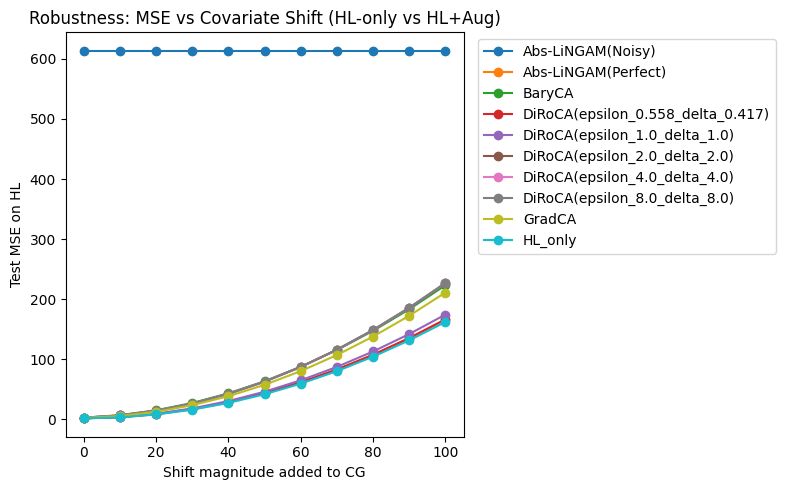

In [22]:
# === Cell 6: Evaluate HL+Aug models under the same covariate shifts and compare ===
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Safety: reuse the same SHIFT_STRENGTHS from Cell 5 (or define if not present)
if "SHIFT_STRENGTHS" not in globals():
    SHIFT_STRENGTHS = np.linspace(0, 100, 11)

def make_shifted_HL_data(X_HL, y_HL, shift_strengths, feature_idx=0):
    """Create shifted copies of X_HL by adding an additive bias to CG (feature_idx)."""
    shifted = {}
    for s in shift_strengths:
        Xs = X_HL.copy()
        Xs[:, feature_idx] = Xs[:, feature_idx] + s
        shifted[s] = (Xs, y_HL)
    return shifted

# Build shifted datasets from clean HL data
X_HL_clean, y_HL_clean = HL_data[_any_method]   # any method has identical HL clean
shifted_HL_sets = make_shifted_HL_data(X_HL_clean, y_HL_clean, SHIFT_STRENGTHS)

# Evaluate: HL-only (for reference, recompute here) + each Aug model under shift
records = []

# 1) HL-only baseline curve (for direct comparison)
y_pred_clean = hl_only_model.predict(X_HL_clean)
mse0 = mean_squared_error(y_HL_clean, y_pred_clean)
records.append({"shift": 0.0, "method": "HL_only", "mse": mse0})

for s, (X_shifted, y_shifted) in shifted_HL_sets.items():
    y_pred_s = hl_only_model.predict(X_shifted)
    mse_s = mean_squared_error(y_shifted, y_pred_s)
    records.append({"shift": float(s), "method": "HL_only", "mse": float(mse_s)})

# 2) HL+Aug models (one curve per method)
for method_name, model in aug_models.items():
    # Evaluate at shift=0 (clean) for reference
    y_pred0 = model.predict(X_HL_clean)
    mse0 = mean_squared_error(y_HL_clean, y_pred0)
    records.append({"shift": 0.0, "method": method_name, "mse": float(mse0)})

    # Evaluate across shift strengths
    for s, (X_shifted, y_shifted) in shifted_HL_sets.items():
        y_pred_s = model.predict(X_shifted)
        mse_s = mean_squared_error(y_shifted, y_pred_s)
        records.append({"shift": float(s), "method": method_name, "mse": float(mse_s)})

# Assemble results
shift_compare_df = pd.DataFrame(records).drop_duplicates(subset=["shift", "method"])
shift_compare_df = shift_compare_df.sort_values(["method", "shift"]).reset_index(drop=True)

print("--- MSE vs shift (lower is better) ---")
display(shift_compare_df.head(20))

# Optional: wide table + 'gain' vs HL_only at each shift
wide = shift_compare_df.pivot(index="shift", columns="method", values="mse").sort_index()
if "HL_only" in wide.columns:
    gain_vs_baseline = wide.apply(lambda col: wide["HL_only"] - col, axis=0)
    gain_vs_baseline = gain_vs_baseline.drop(columns=["HL_only"], errors="ignore")
    print("\n--- Gain vs HL_only (positive = better than HL_only) ---")
    display(gain_vs_baseline.round(4))

# Optional: plot curves
plt.figure(figsize=(8, 5))
for method in wide.columns:
    plt.plot(wide.index, wide[method], marker='o', label=method)
plt.xlabel("Shift magnitude added to CG")
plt.ylabel("Test MSE on HL")
plt.title("Robustness: MSE vs Covariate Shift (HL-only vs HL+Aug)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


=== Average MSE across all shift levels ===


,avg_mse
method,
HL_only,57.634626
Abs-LiNGAM(Perfect),59.167043
DiRoCA(epsilon_0.558_delta_0.417),59.610906
DiRoCA(epsilon_1.0_delta_1.0),62.667011
GradCA,76.973534
BaryCA,83.056460
DiRoCA(epsilon_2.0_delta_2.0),83.409384
DiRoCA(epsilon_4.0_delta_4.0),83.409384
DiRoCA(epsilon_8.0_delta_8.0),83.409384



=== Robustness slope (lower = more stable under shift) ===


,method,mse_slope
0,Abs-LiNGAM(Noisy),-3.476411e-15
9,HL_only,1.604956e+00
1,Abs-LiNGAM(Perfect),1.644138e+00
3,DiRoCA(epsilon_0.558_delta_0.417),1.648262e+00
4,DiRoCA(epsilon_1.0_delta_1.0),1.728171e+00
8,GradCA,2.089345e+00
2,BaryCA,2.205691e+00
5,DiRoCA(epsilon_2.0_delta_2.0),2.242735e+00
6,DiRoCA(epsilon_4.0_delta_4.0),2.242735e+00
7,DiRoCA(epsilon_8.0_delta_8.0),2.242735e+00


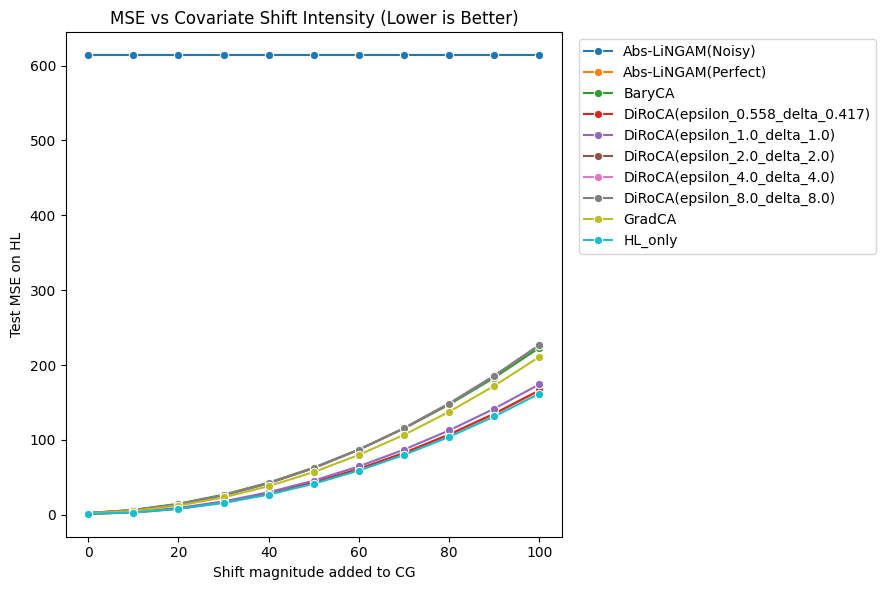


🏆 Most robust abstraction method: **Abs-LiNGAM(Noisy)** (lowest slope)


In [23]:
# === Cell 7: Summarize and visualize robustness trends ===
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure shift_compare_df exists (from Cell 6)
assert "shift_compare_df" in globals(), "Run Cell 6 first to produce shift_compare_df"

# Compute mean MSE across shifts for each method
mean_mse_by_method = shift_compare_df.groupby("method")["mse"].mean().sort_values()
print("=== Average MSE across all shift levels ===")
display(mean_mse_by_method.to_frame().rename(columns={"mse": "avg_mse"}))

# Compute slope of MSE vs shift (robustness indicator: lower slope = more robust)
def mse_slope(df):
    x, y = df["shift"].values, df["mse"].values
    A = np.vstack([x, np.ones_like(x)]).T
    slope, intercept = np.linalg.lstsq(A, y, rcond=None)[0]
    return slope

slope_df = (
    shift_compare_df.groupby("method")
    .apply(mse_slope)
    .reset_index()
    .rename(columns={0: "mse_slope"})
    .sort_values("mse_slope")
)
print("\n=== Robustness slope (lower = more stable under shift) ===")
display(slope_df)

# Plot robustness curves with smooth lines
plt.figure(figsize=(9, 6))
sns.lineplot(data=shift_compare_df, x="shift", y="mse", hue="method", marker="o")
plt.title("MSE vs Covariate Shift Intensity (Lower is Better)")
plt.xlabel("Shift magnitude added to CG")
plt.ylabel("Test MSE on HL")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Highlight the most robust method
best_method = slope_df.iloc[0]["method"]
print(f"\n🏆 Most robust abstraction method: **{best_method}** (lowest slope)")
